In [1]:
'''
TODO:
- push data changes (contiguous splits)
- pull on vm and rerun optima/refitting/then this notebook
'''

'\nTODO:\n- push data changes (contiguous splits)\n- pull on vm and rerun optima/refitting/then this notebook\n'

In [1]:
%load_ext autoreload
%autoreload 2

import importlib
import utils
import ssm

In [2]:
import torch
from gru.model import RateGRU
from utils.data import get_data, get_dmat, reshape_XY

hparams_early = {'learning_rate': 0.005890226144892463, 'batch_size': 16, 'hidden_dim': 64} 
hparams_late  = {'learning_rate': 0.005159359140529756, 'batch_size': 16, 'hidden_dim': 64}


data_early = get_data("early")
data_late  = get_data("late")

gru_early = RateGRU(
    input_size=data_early['X_train'].shape[-1],
    hidden_size=hparams_early['hidden_dim'],
    output_size=data_early['Y_train'].shape[-1]
)
gru_late = RateGRU(
    input_size=data_late['X_train'].shape[-1],
    hidden_size=hparams_late['hidden_dim'],
    output_size=data_late['Y_train'].shape[-1]
)

ckp_early = torch.load("../vars/gru_early_best.pt", weights_only=False)
gru_early.load_state_dict(ckp_early["model_state_dict"])

ckp_late = torch.load("../vars/gru_late_best.pt", weights_only=False)
gru_late.load_state_dict(ckp_late["model_state_dict"])

<All keys matched successfully>

In [ ]:
ckp_early['best_val_r2']
ckp_early['loss_history']
ckp_early['train_r2_history']
ckp_early['val_r2_history']

np.float32(0.25266978)

In [4]:
ckp_late['best_val_r2']

np.float32(0.36254597)

### Early

In [4]:
BWMS=10
s_per_trial=3
b_per_sec   = int(1000/BWMS)
b_per_trial = b_per_sec*s_per_trial

X_early, Y_early = get_dmat("early")
X_early, Y_early = reshape_XY(X_early, Y_early, b_per_trial)

In [5]:
_, h_early = gru_early.gru(torch.tensor(X_early, dtype=torch.float32))

In [6]:
h_early = h_early.detach().numpy().squeeze()

In [7]:
obs_dim   = hparams_early['hidden_dim']
state_dim = 2

print("Fitting LDS with Laplace-EM using structured variational posterior")
lds = ssm.LDS(obs_dim, state_dim, emissions="gaussian")
elbos, q = lds.fit(h_early, method="laplace_em", num_iters=10)

# get the posterior mean of the continuous states
state_means = q.mean_continuous_states[0]

# smooth the data under the variational posterior
smoothed_obs = lds.smooth(state_means, h_early)

Fitting LDS with Laplace-EM using structured variational posterior


  0%|          | 0/1 [00:00<?, ?it/s]

Initializing with an ARHMM using 25 steps of EM.


  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

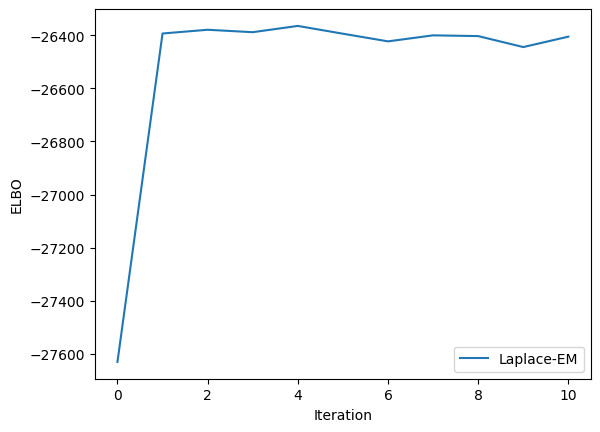

In [8]:
import matplotlib.pyplot as plt

plt.plot(elbos, label="Laplace-EM")
plt.xlabel("Iteration")
plt.ylabel("ELBO")
plt.legend()

In [9]:
import seaborn as sns
color_names = ["windows blue",
               "red",
               "amber",
               "faded green",
               "dusty purple",
               "orange",
               "clay",
               "pink",
               "greyish",
               "mint",
               "light cyan",
               "steel blue",
               "forest green",
               "pastel purple",
               "salmon",
               "dark brown"]

colors = sns.xkcd_palette(color_names)

findfont: Font family ['cmsy10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmr10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmtt10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmmi10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmb10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmss10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmex10'] not found. Falling back to DejaVu Sans.


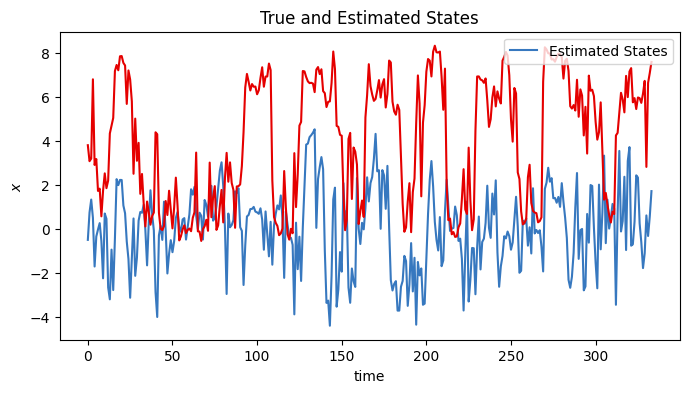

In [10]:
plt.figure(figsize=(8,4))
for d in range(state_dim):
    plt.plot(state_means[:,d] + 4 * d, '-', color=colors[d], label="Estimated States" if d==0 else None)
plt.ylabel("$x$")
plt.xlabel("time")
plt.legend(loc='upper right')
plt.title("True and Estimated States")
plt.show()

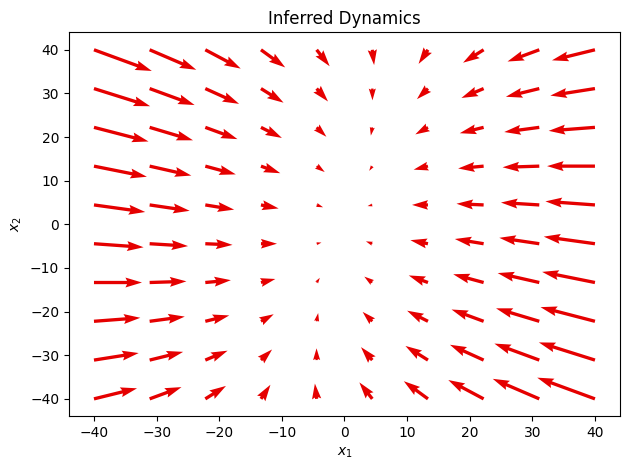

In [11]:
from ssm.plots import plot_dynamics_2d

A_early = lds.dynamics.A
b_early = lds.dynamics.b

fig, ax = plt.subplots()
plot_dynamics_2d(A_early, b_early, npts=10, axis=ax, color=colors[1])
ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")
ax.set_title("Inferred Dynamics")

plt.tight_layout()

In [12]:
from numpy.linalg import eig

eig_early = eig(A_early)

In [24]:
eig_early

EigResult(eigenvalues=array([0.47832699, 0.85032172]), eigenvectors=array([[-0.98903585, -0.20294079],
       [ 0.14767562, -0.97919101]]))

### Late

In [ ]:
BWMS=10
s_per_trial=3
b_per_sec   = int(1000/BWMS)
b_per_trial = b_per_sec*s_per_trial

X_late, Y_late = get_dmat("late")
X_late, Y_late = reshape_XY(X_late, Y_late, b_per_trial)

In [14]:
_, h_late = gru_late.gru(torch.tensor(X_late, dtype=torch.float32))

In [15]:
h_late = h_late.detach().numpy().squeeze()

In [16]:
obs_dim   = hparams_late['hidden_dim']
state_dim = 2

print("Fitting LDS with Laplace-EM using structured variational posterior")
lds = ssm.LDS(obs_dim, state_dim, emissions="gaussian")
elbos, q = lds.fit(h_late, method="laplace_em", num_iters=10)

# get the posterior mean of the continuous states
state_means = q.mean_continuous_states[0]

# smooth the data under the variational posterior
smoothed_obs = lds.smooth(state_means, h_late)

Fitting LDS with Laplace-EM using structured variational posterior


  0%|          | 0/1 [00:00<?, ?it/s]

Initializing with an ARHMM using 25 steps of EM.


  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

In [17]:
# Best hyperparameters found: {'learning_rate': 0.005890226144892463, 'batch_size': 16, 'hidden_dim': 64}
# Best validation metric: 0.22334155440330505 early

# Best hyperparameters found: {'learning_rate': 0.005159359140529756, 'batch_size': 16, 'hidden_dim': 64}
# Best validation metric: 0.29867881536483765 late

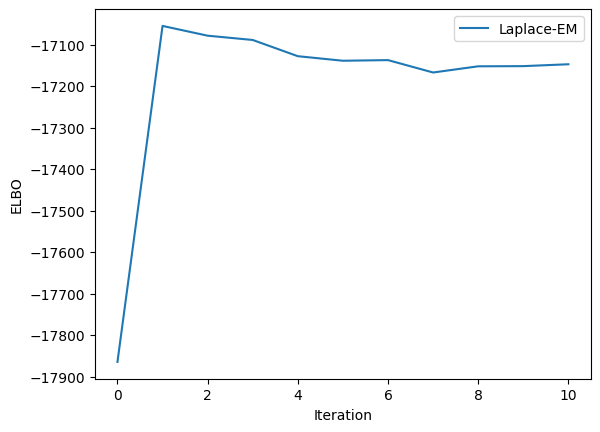

In [18]:
import matplotlib.pyplot as plt

plt.plot(elbos, label="Laplace-EM")
plt.xlabel("Iteration")
plt.ylabel("ELBO")
plt.legend()

In [19]:
import seaborn as sns
color_names = ["windows blue",
               "red",
               "amber",
               "faded green",
               "dusty purple",
               "orange",
               "clay",
               "pink",
               "greyish",
               "mint",
               "light cyan",
               "steel blue",
               "forest green",
               "pastel purple",
               "salmon",
               "dark brown"]

colors = sns.xkcd_palette(color_names)

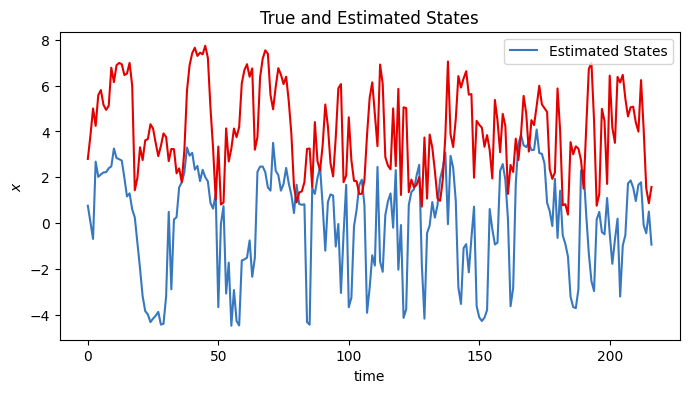

In [20]:
plt.figure(figsize=(8,4))
for d in range(state_dim):
    plt.plot(state_means[:,d] + 4 * d, '-', color=colors[d], label="Estimated States" if d==0 else None)
plt.ylabel("$x$")
plt.xlabel("time")
plt.legend(loc='upper right')
plt.title("True and Estimated States")
plt.show()

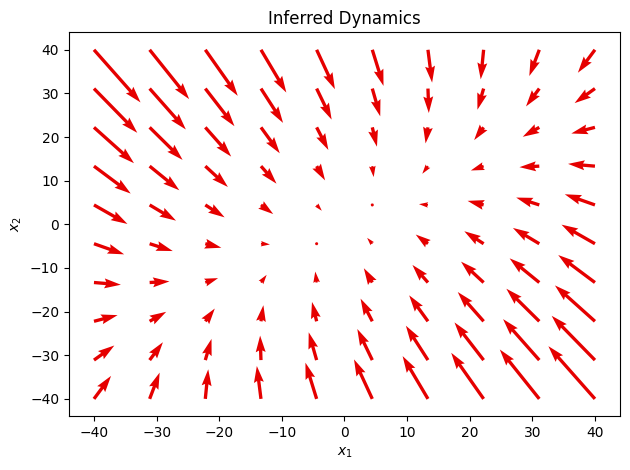

In [21]:
from ssm.plots import plot_dynamics_2d

A_late = lds.dynamics.A
b_late = lds.dynamics.b

fig, ax = plt.subplots()
plot_dynamics_2d(A_late, b_late, npts=10, axis=ax, color=colors[1])
ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")
ax.set_title("Inferred Dynamics")

plt.tight_layout()

In [22]:
from numpy.linalg import eig

eig_late = eig(A_late)

In [23]:
eig_late

EigResult(eigenvalues=array([0.77333727, 0.4261574 ]), eigenvectors=array([[ 0.77297711, -0.63177176],
       [ 0.63443392,  0.77515446]]))